# **Cardiovascular Risk Assessment & Predictive Analytics**

###   A Data-Driven Study of Demographic, Physiological and Lifestyle Determinants of CVD

## **Literature Review**

Recent studies have used this dataset for **CVD prediction, risk-factor analysis, feature selection, and interpretable machine learning**.
This Kaggle CVD dataset provides a useful foundation for studying the relationship between **demographic, physiological, metabolic, and lifestyle factors** and cardiovascular disease, while also supporting **EDA, statistical analysis, and machine-learning prediction**.

source:

https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset

---
### Key Studies

**Yu et al. (2025) – BMC Public Health**  
Developed an interpretable deep-learning model using around 68,000 records from the Kaggle CVD dataset. The study compared several ML models and identified **diastolic BP, cholesterol, systolic BP, and age** among the important predictors.

https://link.springer.com/article/10.1186/s12889-025-24921-4

**Kahraman (2025) – Frontiers in Artificial Intelligence**  
Combined the Kaggle CVD dataset with another large healthcare dataset and compared multiple machine-learning models. The study highlighted the importance of **data preprocessing, class imbalance handling, ensemble models, and model evaluation**.

https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2025.1694450/full

**Banerjee & Paçal (2025) – Systematic Review**  
Reviewed research on machine learning for heart disease prediction. The review highlighted common challenges such as **overfitting, limited external validation, and lack of model interpretability**, and emphasized methods such as **SHAP and LIME**.

https://pmc.ncbi.nlm.nih.gov/articles/PMC12614364/

---
##  Commonly Identified CVD Risk Factors
Research using this dataset commonly examines:
### Demographic Factors
- **Age**
- **Gender**
### Physiological & Metabolic Factors
- **Systolic and diastolic blood pressure**
- **Cholesterol**
- **Glucose**
- **BMI** (calculated from height and weight)
### Lifestyle Factors
- **Smoking**
- **Alcohol use**
- **Physical activity**

These factors are frequently investigated for their association with cardiovascular disease and for their usefulness in predictive models.

---
##  Main Research Insights

Across the literature, important areas of CVD prediction include:

- Identifying major **cardiovascular risk factors**
- Comparing **machine-learning classification models**
- Studying **feature importance**
- Handling **data quality and class imbalance**
- Improving **model interpretability**
- Using patient-level factors for **CVD risk prediction**
---

## Dataset Overview

The **Cardiovascular Disease (CVD) Dataset** by *sulianova* contains approximately **70,000 patient records** and is widely used for cardiovascular disease prediction.

### Main Features
- **Demographic:** Age, Gender
- **Physical/Clinical:** Height, Weight, Systolic BP, Diastolic BP
- **Metabolic:** Cholesterol, Glucose
- **Lifestyle:** Smoking, Alcohol, Physical Activity
- **Target:** `cardio`  
  - `0` = No cardiovascular disease
  - `1` = Cardiovascular disease
---

### CENTRAL RESEARCH QUESTION:
#### Which demographic, physiological, and lifestyle factors are associated with cardiovascular disease, and can these factors be used to predict CVD presence?
- What factors are associated with CVD?
- Can those factors help us predict whether CVD is present?

DOMAIN:
Cardiovascular Health / Cardiovascular Risk Assessment

TARGET: cardio

0 = No CVD
1 = CVD

MAJOR FACTOR GROUPS:
1. Demographic
2. Physiological / Metabolic
3. Lifestyle

MAIN ANALYTICAL APPROACH:
EDA → Statistical Analysis → ML Classification → Interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")
df.head(15)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


## Hypothesis :

1 — Demographic Risk Factors

Does age and demographic profile have an association with cardiovascular disease?

2 — Physiological & Metabolic Risk Factors

Are adverse physiological and metabolic measurements associated with a higher prevalence of cardiovascular disease?

3 — Lifestyle Risk Factors

Are lifestyle behaviors associated with cardiovascular disease?

In [3]:
df.shape

(70000, 13)

In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [6]:
# Numerical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [7]:
# Categorical Variable Inspection

categorical_cols = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"]
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index())


--- gender ---
gender
1    45530
2    24470
Name: count, dtype: int64

--- cholesterol ---
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

--- gluc ---
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

--- smoke ---
smoke
0    63831
1     6169
Name: count, dtype: int64

--- alco ---
alco
0    66236
1     3764
Name: count, dtype: int64

--- active ---
active
0    13739
1    56261
Name: count, dtype: int64

--- cardio ---
cardio
0    35021
1    34979
Name: count, dtype: int64


In [8]:
data_dictionary = pd.DataFrame({
    "Variable": [
        "id", "age", "gender", "height", "weight",
        "ap_hi", "ap_lo", "cholesterol", "gluc",
        "smoke", "alco", "active", "cardio"],
     "Description": [
        "Unique record identifier",
        "Age in days",
        "Gender code",
        "Height in centimeters",
        "Weight in kilograms",
        "Systolic blood pressure",
        "Diastolic blood pressure",
        "Cholesterol category",
        "Glucose category",
        "Smoking indicator",
        "Alcohol-use indicator",
        "Physical-activity indicator",
        "Cardiovascular disease indicator"]})
display(data_dictionary)

,Variable,Description
0,id,Unique record identifier
1,age,Age in days
2,gender,Gender code
3,height,Height in centimeters
4,weight,Weight in kilograms
5,ap_hi,Systolic blood pressure
6,ap_lo,Diastolic blood pressure
7,cholesterol,Cholesterol category
8,gluc,Glucose category
9,smoke,Smoking indicator


## DATA CLEANING & PREPROCESSING

In [9]:
display(df.isna().sum())
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0


**there is no missing values  and 0 duplicate rows**

In [10]:
df_raw = df.copy()       # Preserve original data
df_clean = df.copy()     # All cleaning will happen here

print("Original dataset shape :", df_raw.shape)
print("Working dataset shape  :", df_clean.shape)

Original dataset shape : (70000, 13)
Working dataset shape  : (70000, 13)


In [12]:
column_mapping = {
    "age": "age_days",
    "gender": "gender",
    "height": "height_cm",
    "weight": "weight_kg",
    "ap_hi": "systolic_bp",
    "ap_lo": "diastolic_bp",
    "gluc": "glucose",
    "smoke": "smoking",
    "alco": "alcohol_use",
    "active": "physically_active",
    "cardio": "cvd"}

df_clean = df_clean.rename(columns=column_mapping)
df_clean.head()

,id,age_days,gender,height_cm,weight_kg,systolic_bp,diastolic_bp,cholesterol,glucose,smoking,alcohol_use,physically_active,cvd
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## identify clinically suspicious values

In [13]:
print("Systolic BP <= 0:",
      (df_clean["systolic_bp"] <= 0).sum())

print("Diastolic BP <= 0:",
      (df_clean["diastolic_bp"] <= 0).sum())

print("Systolic BP < Diastolic BP:",
      (df_clean["systolic_bp"] < df_clean["diastolic_bp"]).sum())

print("Systolic BP = Diastolic BP:",
      (df_clean["systolic_bp"] == df_clean["diastolic_bp"]).sum())

print("\nHighest systolic values:")
display(df_clean["systolic_bp"].nlargest(10))

print("\nHighest diastolic values:")
display(df_clean["diastolic_bp"].nlargest(10))

Systolic BP <= 0: 7
Diastolic BP <= 0: 22
Systolic BP < Diastolic BP: 1234
Systolic BP = Diastolic BP: 2

Highest systolic values:


40852    16020
25464    14020
25519    14020
46912    14020
47253    14020
55459    13010
55847    13010
7763     11500
51438    11020
69370     2000
Name: systolic_bp, dtype: int64


Highest diastolic values:


43326    11000
2381     10000
23849    10000
68538    10000
43434     9800
6653      9100
12086     9011
32920     9011
15990     8500
44042     8200
Name: diastolic_bp, dtype: int64

In [14]:
invalid_bp_order = df_clean[
    df_clean["systolic_bp"] < df_clean["diastolic_bp"]]
print("Records with systolic BP < diastolic BP:",
      len(invalid_bp_order))

display(invalid_bp_order.head())

Records with systolic BP < diastolic BP: 1234


,id,age_days,gender,height_cm,weight_kg,systolic_bp,diastolic_bp,cholesterol,glucose,smoking,alcohol_use,physically_active,cvd
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1
345,482,18704,1,154,81.0,140,1000,2,1,0,0,1,1


In [15]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
#Investigate height and weight

print("Height < 120 cm:",
      (df_clean["height_cm"] < 120).sum())

print("Height > 220 cm:",
      (df_clean["height_cm"] > 220).sum())

print("Weight < 30 kg:",
      (df_clean["weight_kg"] < 30).sum())

print("Weight > 200 kg:",
      (df_clean["weight_kg"] > 200).sum())

print("\nSmallest heights:")
display(df_clean["height_cm"].nsmallest(5))

print("\nLargest heights:")
display(df_clean["height_cm"].nlargest(5))

print("\nSmallest weights:")
display(df_clean["weight_kg"].nsmallest(5))

print("\nLargest weights:")
display(df_clean["weight_kg"].nlargest(5))

Height < 120 cm: 52
Height > 220 cm: 1
Weight < 30 kg: 7
Weight > 200 kg: 0

Smallest heights:


22723    55
66643    57
64115    59
29157    60
27603    64
Name: height_cm, dtype: int64


Largest heights:


6486     250
21628    207
41901    200
1117     198
3237     198
Name: height_cm, dtype: int64


Smallest weights:


57858    10.0
33817    11.0
60188    21.0
29488    22.0
26806    23.0
Name: weight_kg, dtype: float64


Largest weights:


435      200.0
50413    200.0
61285    183.0
36780    181.0
4743     180.0
Name: weight_kg, dtype: float64

In [17]:
# ---------- Validation rules ----------

# Project-specific adult plausibility bounds
invalid_height = (
    (df_clean["height_cm"] < 120) |
    (df_clean["height_cm"] > 220))

invalid_weight = (
    (df_clean["weight_kg"] < 30) |
    (df_clean["weight_kg"] > 200))

# Clearly implausible / erroneous BP values
invalid_systolic = (
    (df_clean["systolic_bp"] < 80) |
    (df_clean["systolic_bp"] > 200)
)

invalid_diastolic = (
    (df_clean["diastolic_bp"] < 50) |
    (df_clean["diastolic_bp"] > 150)
)

# Systolic should be greater than diastolic
invalid_bp_order = (
    df_clean["systolic_bp"] <= df_clean["diastolic_bp"]
)

invalid_cholesterol = ~df_clean["cholesterol"].isin([1, 2, 3])
invalid_glucose = ~df_clean["glucose"].isin([1, 2, 3])

invalid_smoking = ~df_clean["smoking"].isin([0, 1])
invalid_alcohol = ~df_clean["alcohol_use"].isin([0, 1])
invalid_activity = ~df_clean["physically_active"].isin([0, 1])

invalid_target = ~df_clean["cvd"].isin([0, 1])

In [18]:
#  Quantify candidate invalid records

print("BLOOD PRESSURE")
print("-" * 40)

print("Systolic BP <= 0:",(df_clean["systolic_bp"] <= 0).sum())

print("Diastolic BP <= 0:",(df_clean["diastolic_bp"] <= 0).sum())

print("Systolic BP < Diastolic BP:",(df_clean["systolic_bp"] < df_clean["diastolic_bp"]).sum())

print("Systolic BP > 240:",(df_clean["systolic_bp"] > 240).sum())

print("Diastolic BP > 140:",(df_clean["diastolic_bp"] > 140).sum())

print("\nHEIGHT")
print("-" * 40)

print("Height < 120 cm:",(df_clean["height_cm"] < 120).sum())

print("Height > 207 cm:",(df_clean["height_cm"] > 207).sum())

print("\nWEIGHT")
print("-" * 40)

print("Weight < 30 kg:",(df_clean["weight_kg"] < 30).sum())

print("Weight > 200 kg:",(df_clean["weight_kg"] > 200).sum())

BLOOD PRESSURE
----------------------------------------
Systolic BP <= 0: 7
Diastolic BP <= 0: 22
Systolic BP < Diastolic BP: 1234
Systolic BP > 240: 40
Diastolic BP > 140: 983

HEIGHT
----------------------------------------
Height < 120 cm: 52
Height > 207 cm: 1

WEIGHT
----------------------------------------
Weight < 30 kg: 7
Weight > 200 kg: 0


In [19]:
before = len(df_clean)
valid_mask = (
    (df_clean["systolic_bp"] > 0) &
    (df_clean["diastolic_bp"] > 0) &
    (df_clean["systolic_bp"] >= df_clean["diastolic_bp"]) &
    (df_clean["height_cm"] >= 120) &
    (df_clean["weight_kg"] >= 30))
df_clean = df_clean.loc[valid_mask].copy()
after = len(df_clean)
print(f"Records before cleaning : {before:,}")
print(f"Records after cleaning  : {after:,}")
print(f"Records removed         : {before - after:,}")
print(f"Records retained        : {after / before:.2%}")

Records before cleaning : 70,000
Records after cleaning  : 68,688
Records removed         : 1,312
Records retained        : 98.13%


In [20]:
# Validation
print("Remaining invalid BP values:",
      ((df_clean["systolic_bp"] <= 0) |
       (df_clean["diastolic_bp"] <= 0) |
       (df_clean["systolic_bp"] < df_clean["diastolic_bp"])).sum())

print("Remaining height < 120 cm:",
      (df_clean["height_cm"] < 120).sum())

print("Remaining weight < 30 kg:",
      (df_clean["weight_kg"] < 30).sum())

print("\nFinal shape:", df_clean.shape)

Remaining invalid BP values: 0
Remaining height < 120 cm: 0
Remaining weight < 30 kg: 0

Final shape: (68688, 13)


We performed domain-informed data cleaning. 
We retained extreme but clinically plausible observations because they may carry cardiovascular risk information, while removing observations judged to be invalid or inconsistent with the measurement context

## FEATURE ENGINEERING


In [21]:
# 1. Convert age from days to years
df_clean["age_years"] = df_clean["age_days"] / 365.25

df_clean["age_years"] = df_clean["age_years"].round(1)

df_clean[["age_days", "age_years"]].head()

,age_days,age_years
0,18393,50.4
1,20228,55.4
2,18857,51.6
3,17623,48.2
4,17474,47.8


In [22]:
df_clean.drop(columns=["age_days"], inplace=True)

In [23]:
#Calculate BMI

df_clean["height_m"] = df_clean["height_cm"] / 100

df_clean["BMI"] = (df_clean["weight_kg"] / (df_clean["height_m"] ** 2)).round(2)

df_clean[["height_cm", "weight_kg", "BMI"]].head()

,height_cm,weight_kg,BMI
0,168,62.0,21.97
1,156,85.0,34.93
2,165,64.0,23.51
3,169,82.0,28.71
4,156,56.0,23.01


In [24]:
#  Create BMI categories

def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Healthy Weight"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obesity"
df_clean["BMI_category"] = df_clean["BMI"].apply(bmi_category)
df_clean["BMI_category"].value_counts()

BMI_category
Healthy Weight    25326
Overweight        24735
Obesity           17996
Underweight         631
Name: count, dtype: int64

In [25]:
df_clean.drop(columns=["height_m"], inplace=True)

In [26]:
#  Calculate Pulse Pressure [Pulse Pressure=Systolic BP−Diastolic BP ]

df_clean["pulse_pressure"] = (
    df_clean["systolic_bp"] - df_clean["diastolic_bp"])

df_clean[["systolic_bp", "diastolic_bp", "pulse_pressure"]].head()

,systolic_bp,diastolic_bp,pulse_pressure
0,110,80,30
1,140,90,50
2,130,70,60
3,150,100,50
4,100,60,40


In [27]:
# Create Blood Pressure Categories
def bp_category(row):
    systolic = row["systolic_bp"]
    diastolic = row["diastolic_bp"]
    if systolic > 180 or diastolic > 120:
        return "Severe"
    elif systolic >= 140 or diastolic >= 90:
        return "Stage 2 Hypertension"
    elif systolic >= 130 or diastolic >= 80:
        return "Stage 1 Hypertension"
    elif systolic >= 120 and diastolic < 80:
        return "Elevated"
    else:
        return "Normal"

df_clean["BP_category"] = df_clean.apply(bp_category, axis=1)
df_clean["BP_category"].value_counts()

BP_category
Stage 1 Hypertension    32443
Stage 2 Hypertension    23241
Normal                   9556
Elevated                 3119
Severe                    329
Name: count, dtype: int64

In [28]:
# Create Age Groups

bins = [29, 40, 50, 60, 70]
labels = ["30–39", "40–49", "50–59", "60–69"]

df_clean["age_group"] = pd.cut(
    df_clean["age_years"],
    bins=bins,
    labels=labels,
    right=False)
df_clean["age_group"].value_counts().sort_index()

age_group
30–39     1684
40–49    19293
50–59    34884
60–69    12827
Name: count, dtype: int64

In [29]:
df_clean.head()

,id,gender,height_cm,weight_kg,systolic_bp,diastolic_bp,cholesterol,glucose,smoking,alcohol_use,physically_active,cvd,age_years,BMI,BMI_category,pulse_pressure,BP_category,age_group
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.97,Healthy Weight,30,Stage 1 Hypertension,50–59
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.93,Obesity,50,Stage 2 Hypertension,50–59
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.51,Healthy Weight,60,Stage 1 Hypertension,50–59
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.71,Overweight,50,Stage 2 Hypertension,40–49
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.01,Healthy Weight,40,Normal,40–49


## UNIVARIATE EDA

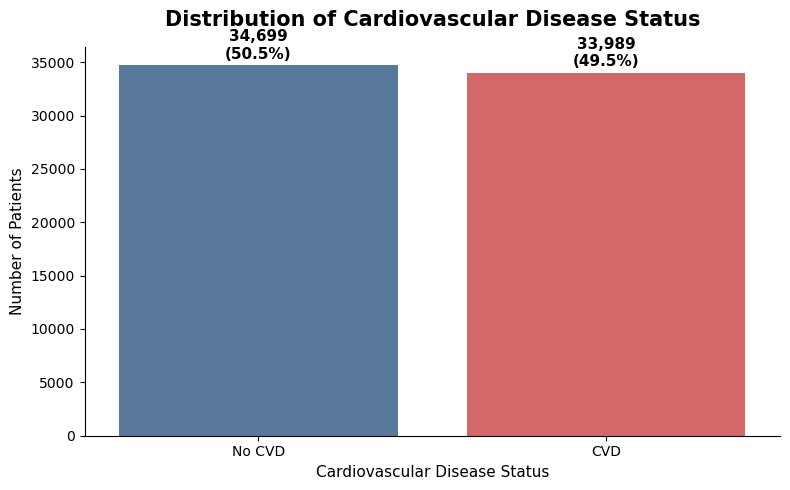

In [30]:
# Calculate counts and percentages

cvd_counts = df_clean["cvd"].value_counts().sort_index()
cvd_percent = df_clean["cvd"].value_counts(normalize=True).sort_index() * 100
# Labels for readability
labels = ["No CVD", "CVD"]
# Custom color palette
colors = ["#4C78A8", "#E45756"]
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=labels,y=cvd_counts.values,hue=labels,palette=colors,legend=False)
plt.title("Distribution of Cardiovascular Disease Status",fontsize=15,fontweight="bold",pad=15)
plt.xlabel("Cardiovascular Disease Status", fontsize=11)
plt.ylabel("Number of Patients", fontsize=11)
# Annotate count + percentage
for i, (count, pct) in enumerate(zip(cvd_counts.values, cvd_percent.values)): ax.text(
        i,count + (count * 0.01),f"{count:,}\n({pct:.1f}%)",
        ha="center",va="bottom",fontsize=11,fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

population contains almost equal numbers of CVD-positive and CVD-negative records. This gives us a reasonably balanced outcome for studying cardiovascular risk patterns and developing classification models.

## Age Distribution :

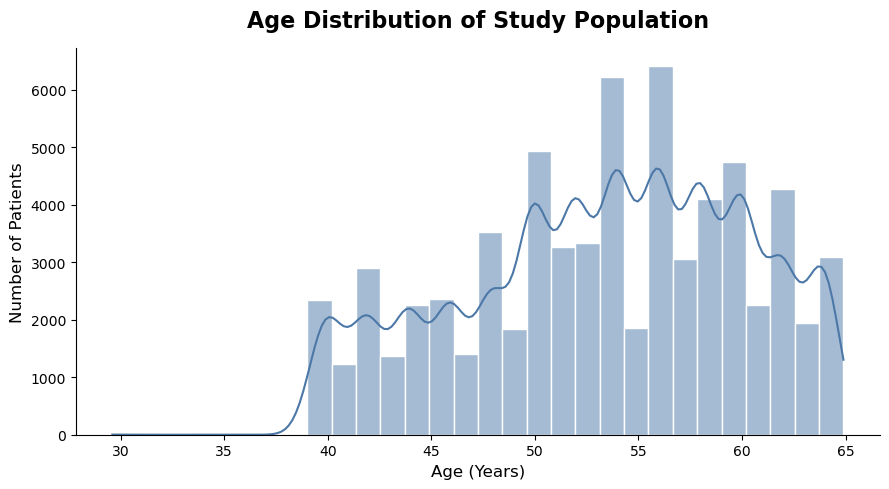

In [31]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_clean,x="age_years",bins=30,
    kde=True,color="#4C78A8",edgecolor="white")
plt.title(
    "Age Distribution of Study Population",fontsize=16,
    fontweight="bold",pad=15)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

**Most people in this dataset are middle-aged or older adults, so age is an important demographic factor to examine in relation to CVD**

## Blood Pressure Distributions

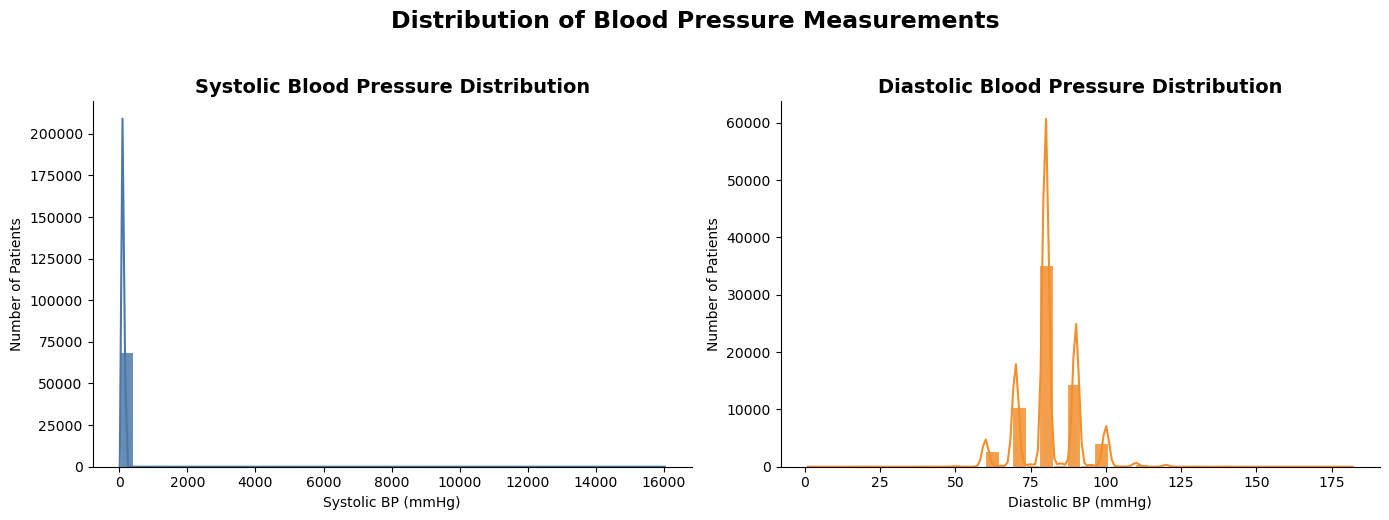

Systolic → Mean: 128.78, Median: 120.00, Skewness: 85.06
Diastolic → Mean: 81.27, Median: 80.00, Skewness: 0.20


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot( df_clean["systolic_bp"],bins=40,kde=True,color="#4C78A8",
    edgecolor="white",alpha=0.85,ax=axes[0])
axes[0].set_title("Systolic Blood Pressure Distribution",
    fontsize=14,fontweight="bold")
axes[0].set_xlabel("Systolic BP (mmHg)")
axes[0].set_ylabel("Number of Patients")
# -------- Diastolic BP --------
sns.histplot(df_clean["diastolic_bp"],bins=40,
    kde=True,color="#F28E2B",edgecolor="white",alpha=0.85,ax=axes[1])
axes[1].set_title(
    "Diastolic Blood Pressure Distribution",
    fontsize=14,fontweight="bold")
axes[1].set_xlabel("Diastolic BP (mmHg)")
axes[1].set_ylabel("Number of Patients")
plt.suptitle("Distribution of Blood Pressure Measurements",
    fontsize=17,fontweight="bold",y=1.03)
sns.despine()
plt.tight_layout()
plt.show()
print(
    f"Systolic → Mean: {df_clean['systolic_bp'].mean():.2f}, "
    f"Median: {df_clean['systolic_bp'].median():.2f}, "
    f"Skewness: {df_clean['systolic_bp'].skew():.2f}")
print(
    f"Diastolic → Mean: {df_clean['diastolic_bp'].mean():.2f}, "
    f"Median: {df_clean['diastolic_bp'].median():.2f}, "
    f"Skewness: {df_clean['diastolic_bp'].skew():.2f}")

- Diastolic BP is concentrated mainly around the normal range, with most values roughly around 70–90 mmHg.
- Systolic BP shows a much wider spread and a strong right tail because of some extremely high measurements.
- Blood pressure varies considerably across the population, particularly systolic pressure, with some patients showing very high readings.
- This indicates that abnormal blood pressure is an important cardiovascular characteristic present in this dataset.

## Distribution of Derived Cardiovascular Health Measures

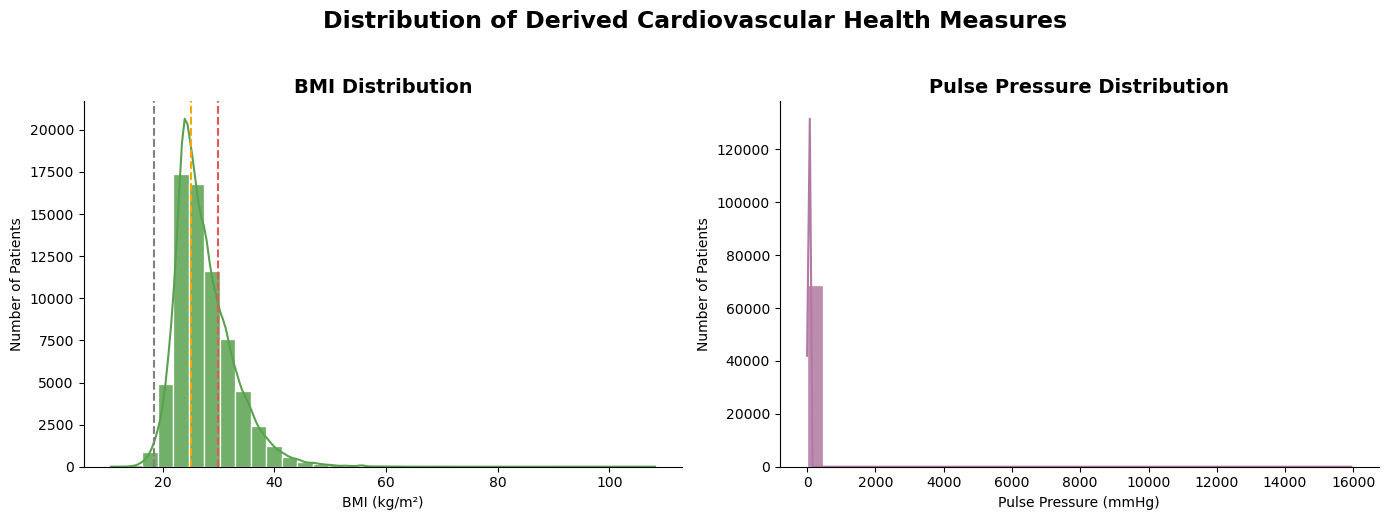

BMI → Mean: 27.46, Median: 26.35, Skewness: 1.35
Pulse Pressure → Mean: 47.50, Median: 40.00, Skewness: 85.81


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# -------- BMI --------
sns.histplot(df_clean["BMI"],bins=35,kde=True,
    color="#59A14F",edgecolor="white", alpha=0.85,ax=axes[0])
# BMI reference lines
axes[0].axvline(18.5,
    color="gray",linestyle="--",linewidth=1.5)
axes[0].axvline(25,color="orange",
    linestyle="--",linewidth=1.5)
axes[0].axvline(30,color="#E45756",
    linestyle="--",linewidth=1.5)
axes[0].set_title(
    "BMI Distribution",fontsize=14,fontweight="bold")
axes[0].set_xlabel("BMI (kg/m²)")
axes[0].set_ylabel("Number of Patients")
# -------- Pulse Pressure --------
sns.histplot(df_clean["pulse_pressure"],
    bins=35,kde=True,color="#B279A2",edgecolor="white",alpha=0.85,ax=axes[1])
axes[1].set_title("Pulse Pressure Distribution",
    fontsize=14,fontweight="bold")
axes[1].set_xlabel("Pulse Pressure (mmHg)")
axes[1].set_ylabel("Number of Patients")
plt.suptitle("Distribution of Derived Cardiovascular Health Measures",
    fontsize=17,fontweight="bold",y=1.03)
sns.despine()
plt.tight_layout()
plt.show()
print(
    f"BMI → Mean: {df_clean['BMI'].mean():.2f}, "
    f"Median: {df_clean['BMI'].median():.2f}, "
    f"Skewness: {df_clean['BMI'].skew():.2f}")
print(
    f"Pulse Pressure → Mean: {df_clean['pulse_pressure'].mean():.2f}, "
    f"Median: {df_clean['pulse_pressure'].median():.2f}, "
    f"Skewness: {df_clean['pulse_pressure'].skew():.2f}")

- **BMI** is concentrated mostly around the normal-to-overweight range, with a noticeable right tail toward higher BMI values.
- The BMI distribution is therefore right-skewed, meaning a smaller group has considerably higher BMI values.
- Most patients have BMI values around the normal-to-overweight range, while a smaller group has substantially higher BMI.

- **Pulse pressure**is concentrated at much lower values, but its graph is strongly distorted by the extreme BP records still present in the dataset.

## Metabolic & Blood Pressure Categories

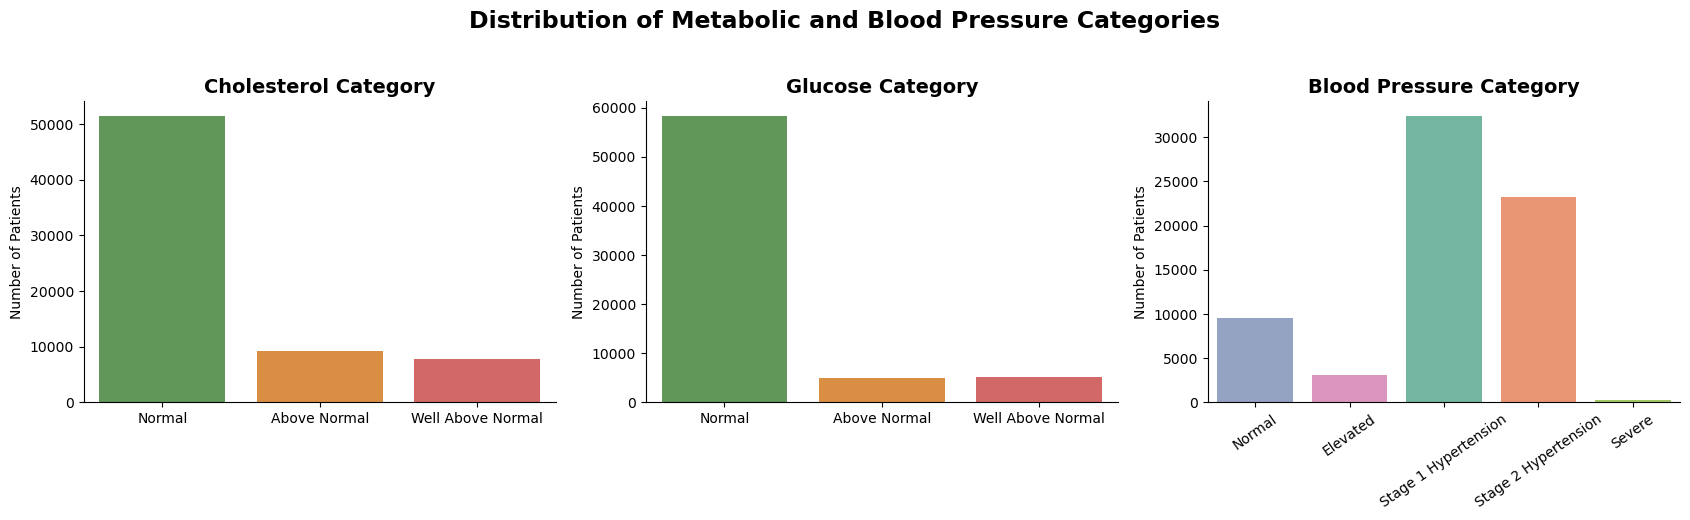

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
# -------- Cholesterol --------
chol_labels = {
    1: "Normal",2: "Above Normal",3: "Well Above Normal"}
chol_order = [1, 2, 3]
sns.countplot(data=df_clean,x="cholesterol",order=chol_order,
    hue="cholesterol",palette=["#59A14F", "#F28E2B", "#E45756"],legend=False,ax=axes[0])
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(
    [chol_labels[x] for x in chol_order])
axes[0].set_title(
    "Cholesterol Category",
    fontsize=14,
    fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Patients")
# -------- Glucose --------
glucose_order = [1, 2, 3]
sns.countplot(
    data=df_clean,x="glucose",order=glucose_order,hue="glucose",
    palette=["#59A14F", "#F28E2B", "#E45756"],legend=False,ax=axes[1])
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(
    [chol_labels[x] for x in glucose_order])
axes[1].set_title(
    "Glucose Category",
    fontsize=14,fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Patients")
# -------- BP Category --------
bp_order = ["Normal", "Elevated",
    "Stage 1 Hypertension","Stage 2 Hypertension","Severe"]
sns.countplot(data=df_clean,
    x="BP_category",order=bp_order,hue="BP_category",
    palette="Set2",legend=False,ax=axes[2])
axes[2].set_title("Blood Pressure Category",fontsize=14,fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Number of Patients")
axes[2].tick_params(axis="x", rotation=35)

plt.suptitle("Distribution of Metabolic and Blood Pressure Categories",
    fontsize=17,fontweight="bold",y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

- **Cholesterol**: Most patients are in the Normal category, while a much smaller proportion have above-normal or well-above-normal cholesterol.

- **Glucose**: The same pattern is visible—most records are Normal, with relatively fewer patients in the elevated categories.

- **Blood pressure**: Stage 1 hypertension is the largest category, followed by Stage 2 hypertension; comparatively fewer patients fall into the Normal or Elevated categories.

- *Normal cholesterol and glucose dominate their distributions, whereas hypertension categories account for a large share of the recorded blood-pressure classifications.*

### Demographic & Lifestyle Characteristics :

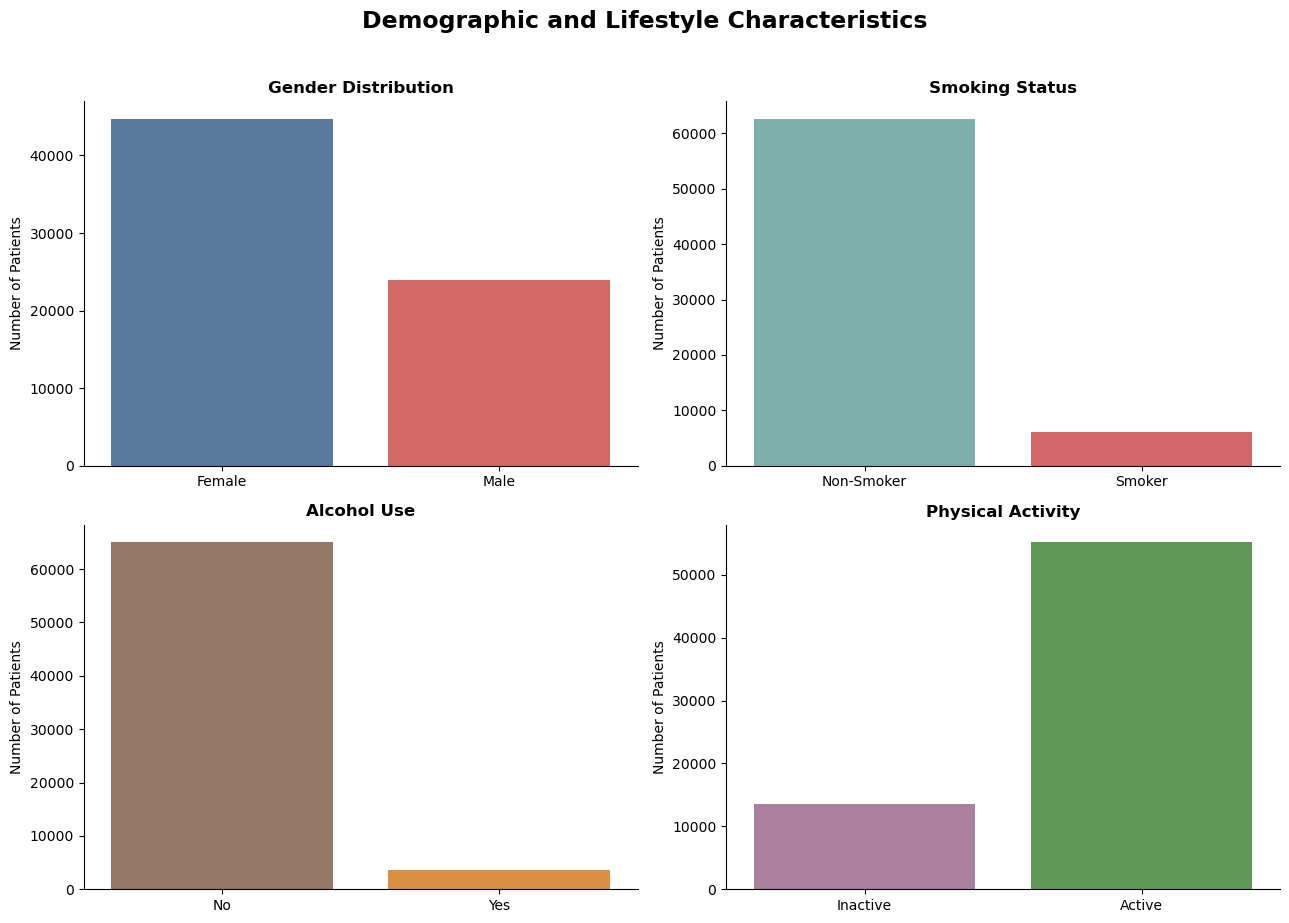

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# -------- Gender --------
gender_order = [1, 2]
sns.countplot(data=df_clean,x="gender",
    order=gender_order,hue="gender",palette=["#4C78A8", "#E45756"],  legend=False,ax=axes[0, 0])
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Female", "Male"])
axes[0, 0].set_title("Gender Distribution", fontweight="bold")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of Patients")
# -------- Smoking --------
sns.countplot(data=df_clean,x="smoking",order=[0, 1],hue="smoking",
    palette=["#76B7B2", "#E15759"],legend=False, ax=axes[0, 1])
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(["Non-Smoker", "Smoker"])
axes[0, 1].set_title("Smoking Status", fontweight="bold")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Number of Patients")
# -------- Alcohol --------
sns.countplot(data=df_clean,x="alcohol_use",order=[0, 1],
    hue="alcohol_use",palette=["#9C755F", "#F28E2B"],legend=False,ax=axes[1, 0])
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["No", "Yes"])
axes[1, 0].set_title("Alcohol Use", fontweight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Number of Patients")
# -------- Physical Activity --------
sns.countplot(data=df_clean,x="physically_active",order=[0, 1],
    hue="physically_active",palette=["#B07AA1", "#59A14F"],legend=False,ax=axes[1, 1])
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Inactive", "Active"])
axes[1, 1].set_title("Physical Activity", fontweight="bold")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Number of Patients")
plt.suptitle("Demographic and Lifestyle Characteristics",
    fontsize=17,fontweight="bold",y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

- The dataset contains more females than males.
- Non-smokers greatly outnumber smokers.
- Non-alcohol users greatly outnumber alcohol users.
- Most participants are classified as physically active, while inactive participants form a smaller group.
- Therefore, the dataset is not evenly distributed across these demographic and lifestyle characteristics.
- *Female, non-smoking, non-alcohol-use and physically active participants make up the majority of the study population.*

## BIVARIATE ANALYSIS :

### DEMOGRAPHIC FACTOR vs CVD

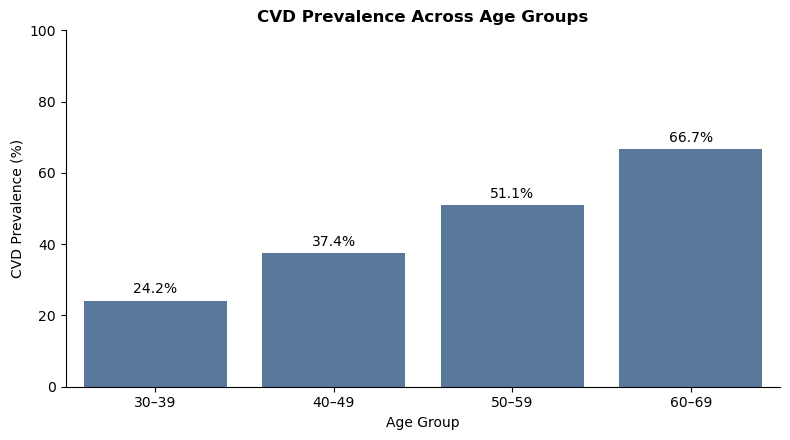

In [36]:
# Age Group vs CVD
d = df_clean.groupby("age_group",observed=True)["cvd"].mean().mul(100).reset_index()
plt.figure(figsize=(8,4.5))
ax = sns.barplot(data=d, x="age_group", y="cvd", color="#4C78A8")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.title("CVD Prevalence Across Age Groups", fontweight="bold")
plt.xlabel("Age Group"); plt.ylabel("CVD Prevalence (%)")
plt.ylim(0,100); sns.despine(); plt.tight_layout(); plt.show()

- CVD prevalence increases clearly with age.
- It rises from 24.2% in 30–39 to 66.7% in 60–69. The increase is consistent across every age group.
- Older age groups in this dataset show a much higher prevalence of CVD.
This suggests that age is an important factor associated with cardiovascular disease.

## BP CATEGORY vs CVD

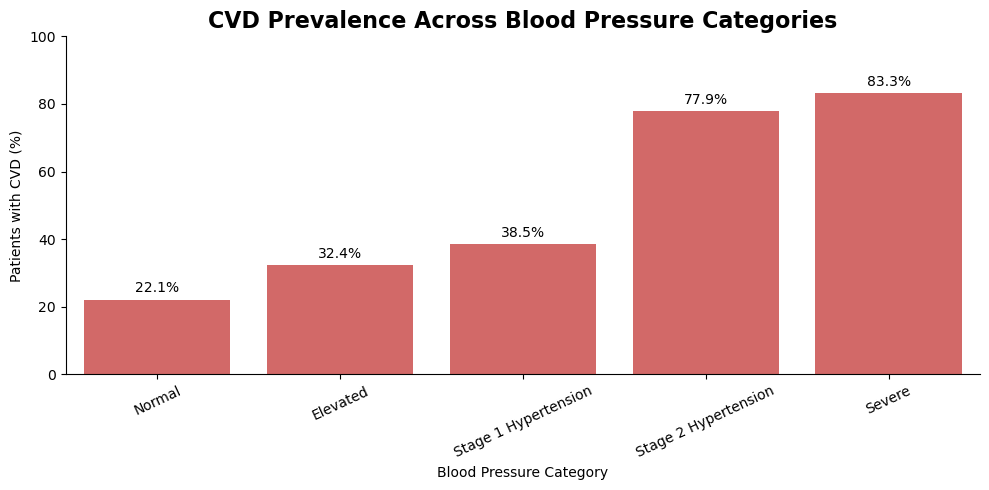

In [37]:
bp_cvd = (
    df_clean.groupby("BP_category")["cvd"]
    .mean()
    .mul(100)
    .reset_index(name="CVD_Percentage"))
bp_order = [
    "Normal",
    "Elevated",
    "Stage 1 Hypertension",
    "Stage 2 Hypertension",
    "Severe"]
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=bp_cvd,x="BP_category",
    y="CVD_Percentage",order=bp_order,color="#E45756")
for container in ax.containers:
    ax.bar_label(
        container,fmt="%.1f%%",padding=3,fontsize=10)
plt.title(
    "CVD Prevalence Across Blood Pressure Categories",
    fontsize=16,fontweight="bold")
plt.xlabel("Blood Pressure Category")
plt.ylabel("Patients with CVD (%)")
plt.xticks(rotation=25)
plt.ylim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

- There is a very clear increase in CVD prevalence as BP category becomes more severe.
- Normal BP: 22.1% , Elevated: 32.4% , Stage 1: 38.5% , Stage 2: 77.9% , Severe: 83.3%
- The jump becomes particularly large from Stage 1 → Stage 2.
- *higher BP is associated with higher CVD prevalence*

## BMI CATEGORY vs CVD

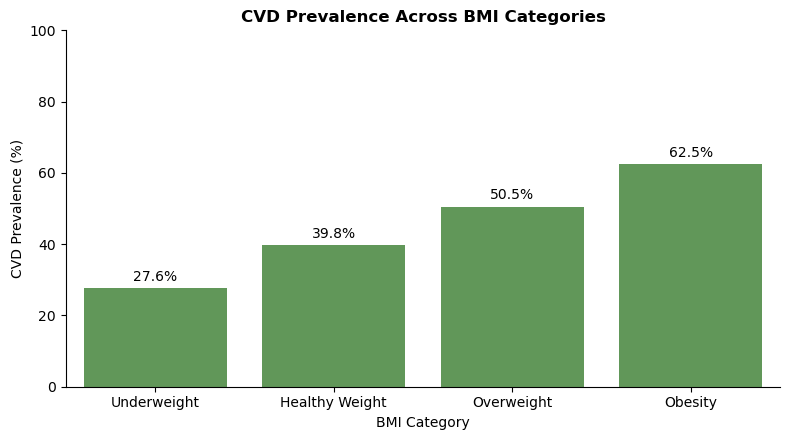

In [38]:
order = ["Underweight","Healthy Weight","Overweight","Obesity"]
d = df_clean.groupby("BMI_category")["cvd"].mean().mul(100).reindex(order).reset_index()
plt.figure(figsize=(8,4.5))
ax = sns.barplot(data=d, x="BMI_category", y="cvd", color="#59A14F")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.title("CVD Prevalence Across BMI Categories", fontweight="bold")
plt.xlabel("BMI Category"); plt.ylabel("CVD Prevalence (%)")
plt.ylim(0,100); sns.despine(); plt.tight_layout(); plt.show()

- CVD prevalence generally increases as BMI category increases.
- Underweight: 27.6%, Healthy Weight: 39.8% ,Overweight: 50.5% , Obesity: 62.5%
- The pattern is quite consistent, with obesity showing the highest prevalence.

## Lifestyle Factors vs CVD

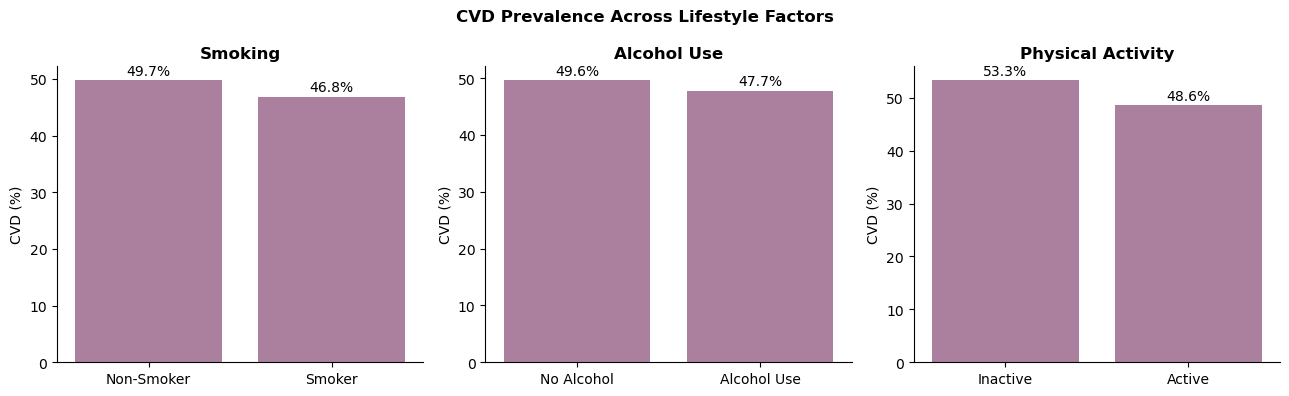

In [39]:
fig, axes = plt.subplots(1,3,figsize=(13,4))
vars_ = [("smoking",["Non-Smoker","Smoker"],"Smoking"),
         ("alcohol_use",["No Alcohol","Alcohol Use"],"Alcohol Use"),
         ("physically_active",["Inactive","Active"],"Physical Activity")]
for ax,(col,labels,title) in zip(axes,vars_):
    d = df_clean.groupby(col)["cvd"].mean().mul(100).reset_index()
    sns.barplot(data=d,x=col,y="cvd",color="#B279A2",ax=ax)
    ax.set_title(title,fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel("CVD (%)")
    ax.set_xticks(range(2)); ax.set_xticklabels(labels)
    ax.bar_label(ax.containers[0],fmt="%.1f%%",padding=2)

plt.suptitle("CVD Prevalence Across Lifestyle Factors",fontweight="bold")
sns.despine(); plt.tight_layout(); plt.show()

- **Smoking**: CVD prevalence is quite similar between non-smokers (49.7%) and smokers (46.8%).
- **Alcohol**: The difference is also small — 49.6% vs 47.7%.
- **Physical activity**: Inactive participants show higher CVD prevalence (53.3%) than active participants (48.6%).
- Among these three lifestyle factors, physical activity shows the clearest difference, although it is still modest.

## MULTIVARIATE ANALYSIS :

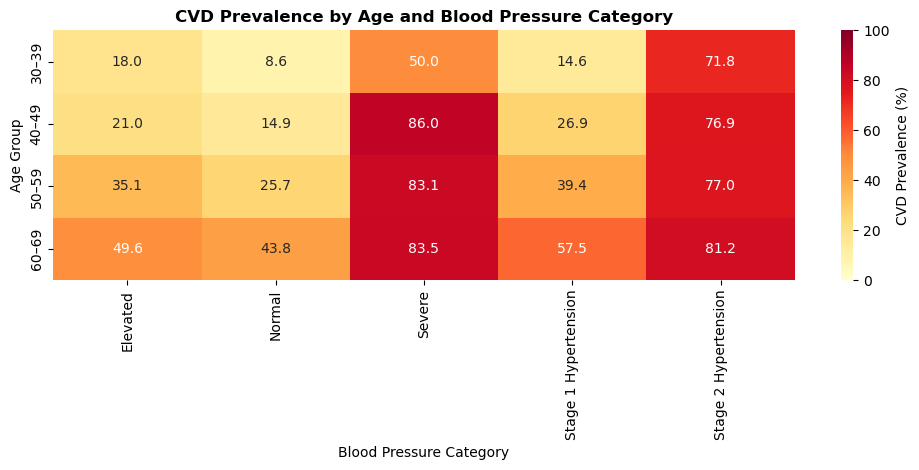

In [40]:
# Age × BP Category × CVD
d = pd.crosstab(df_clean["age_group"],df_clean["BP_category"],values=df_clean["cvd"],aggfunc="mean").mul(100)
plt.figure(figsize=(10,4.8))
sns.heatmap(d,annot=True,fmt=".1f",cmap="YlOrRd",vmin=0,vmax=100,cbar_kws={"label":"CVD Prevalence (%)"})
plt.title("CVD Prevalence by Age and Blood Pressure Category",fontweight="bold")
plt.xlabel("Blood Pressure Category"); plt.ylabel("Age Group")
plt.tight_layout(); plt.show()

- CVD prevalence generally increases with age across the BP categories.
- The difference becomes especially clear in the Stage 2 and Severe BP groups.
- Severe BP shows consistently high CVD prevalence across all age groups, around 72–81%.
- The combination of older age + higher BP shows the strongest CVD prevalence pattern.


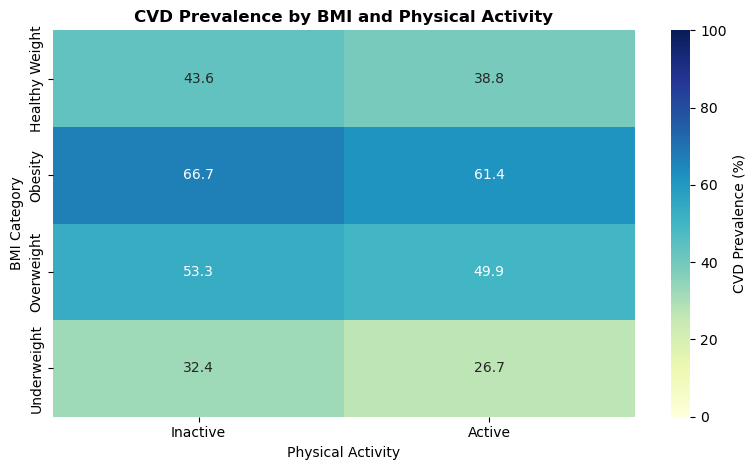

In [41]:
# BMI × Physical Activity × CVD
d = pd.crosstab(df_clean["BMI_category"],df_clean["physically_active"],values=df_clean["cvd"],aggfunc="mean").mul(100)
d.columns = ["Inactive","Active"]
plt.figure(figsize=(8,4.8))
sns.heatmap(d,annot=True,fmt=".1f",cmap="YlGnBu",vmin=0,vmax=100,cbar_kws={"label":"CVD Prevalence (%)"})
plt.title("CVD Prevalence by BMI and Physical Activity",fontweight="bold")
plt.xlabel("Physical Activity"); plt.ylabel("BMI Category")
plt.tight_layout(); plt.show()

- CVD prevalence increases substantially as BMI moves from underweight → overweight → obesity.
- Within every BMI category, inactive participants have higher CVD prevalence than active participants.
- The difference is particularly visible in the healthy-weight and overweight groups.
- Obesity combined with inactivity has the highest prevalence: 66.7%

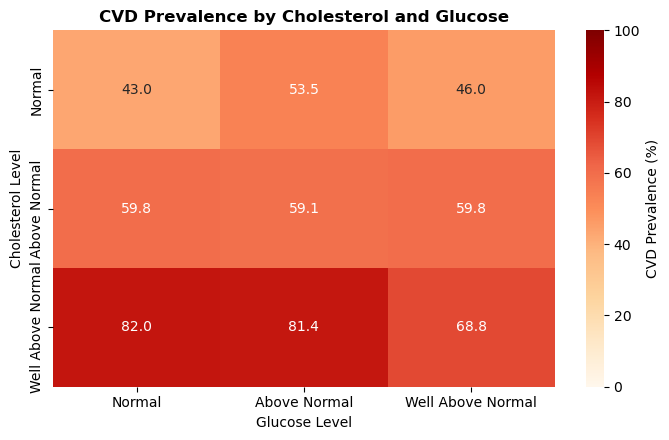

In [42]:
# Cholesterol × Glucose × CVD
d=df_clean.pivot_table(index="cholesterol",columns="glucose",values="cvd",aggfunc="mean",observed=True)*100
d=d.reindex(index=[1,2,3],columns=[1,2,3])
d.index=["Normal","Above Normal","Well Above Normal"]
d.columns=["Normal","Above Normal","Well Above Normal"]
plt.figure(figsize=(7,4.5))
sns.heatmap(d,annot=True,fmt=".1f",cmap="OrRd",vmin=0,vmax=100,cbar_kws={"label":"CVD Prevalence (%)"})
plt.title("CVD Prevalence by Cholesterol and Glucose",fontweight="bold")
plt.xlabel("Glucose Level");plt.ylabel("Cholesterol Level");plt.tight_layout();plt.show()

- Cholesterol shows a much clearer pattern than glucose in this heatmap.
- CVD prevalence rises strongly from Normal → Above Normal → Well Above Normal cholesterol.
- In the Well Above Normal cholesterol group, CVD prevalence is very high across all glucose categories: 68.8–82.0%.
- Glucose differences within the same cholesterol level are comparatively smaller.
- cholesterol has a stronger visible association with CVD than glucose.

## Crosstab: important variables vs CVD (%)

In [43]:
vars=["age_group","BP_category","BMI_category","cholesterol","glucose","gender","smoking","alcohol_use","physically_active"]
for col in vars:
    ct=pd.crosstab(df_clean[col],df_clean["cvd"],normalize="index").mul(100).round(1)
    print(f"\n--- {col} ---");print(ct.rename(columns={0:"No CVD (%)",1:"CVD (%)"}))


--- age_group ---
cvd        No CVD (%)  CVD (%)
age_group                     
30–39            75.8     24.2
40–49            62.6     37.4
50–59            48.9     51.1
60–69            33.3     66.7

--- BP_category ---
cvd                   No CVD (%)  CVD (%)
BP_category                              
Elevated                    67.6     32.4
Normal                      77.9     22.1
Severe                      16.7     83.3
Stage 1 Hypertension        61.5     38.5
Stage 2 Hypertension        22.1     77.9

--- BMI_category ---
cvd             No CVD (%)  CVD (%)
BMI_category                       
Healthy Weight        60.2     39.8
Obesity               37.5     62.5
Overweight            49.5     50.5
Underweight           72.4     27.6

--- cholesterol ---
cvd          No CVD (%)  CVD (%)
cholesterol                     
1                  56.4     43.6
2                  40.4     59.6
3                  23.7     76.3

--- glucose ---
cvd      No CVD (%)  CVD (%)
glucose   

# EDA Conclusions — Before ML Preprocessing

- **Age:** CVD prevalence increases clearly with age.
- **Blood Pressure:** Higher BP categories show much higher CVD prevalence.
- **BMI:** CVD prevalence increases from healthy weight to obesity.
- **Cholesterol:** Higher cholesterol levels are strongly associated with higher CVD prevalence.
- **Glucose:** Shows a weaker and less consistent relationship with CVD.
- **Gender:** The dataset contains more females than males.
- **Smoking:** CVD prevalence is similar between smokers and non-smokers.
- **Alcohol Use:** Only a small difference is seen between users and non-users.
- **Physical Activity:** Inactive people show somewhat higher CVD prevalence.
- **Combined Factors:** Older age, higher BP, higher BMI, and high cholesterol together show particularly high CVD prevalence.
---
## Overall Summary

- CVD is associated with **multiple demographic, physical, metabolic, and lifestyle factors**.
- **Age, blood pressure, BMI, and cholesterol** show the clearest patterns.
- In simple terms, **unhealthy physical and metabolic profiles are more commonly seen among people with CVD in this dataset**.

**The overall pattern suggests that cardiovascular disease is associated with a combination of demographic, physical, metabolic, and lifestyle factors rather than one single cause.**

##  Target leakage check

In [45]:
# Target leakage check
target="cvd"
features=[c for c in df_clean.columns if c!=target]
print("Target:",target)
print("Features containing target name:",[c for c in features if target in c.lower()])
print("\nFeature columns:")
print(features)

Target: cvd
Features containing target name: []

Feature columns:
['id', 'gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'glucose', 'smoking', 'alcohol_use', 'physically_active', 'age_years', 'BMI', 'BMI_category', 'pulse_pressure', 'BP_category', 'age_group']


No direct target leakage is present in the engineered features

## Random-Noise Feature Check

In [46]:
# Random-noise feature check
from sklearn.ensemble import RandomForestClassifier
features=["age_years","gender","height_cm","weight_kg","systolic_bp","diastolic_bp","cholesterol","glucose","smoking","alcohol_use","physically_active","BMI","pulse_pressure"]
X=df_clean[features].copy(); y=df_clean["cvd"]
X["random_noise"]=np.random.RandomState(42).normal(size=len(X))

rf=RandomForestClassifier(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1)
rf.fit(X,y)

imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)
print(imp)
print("\nRandom noise importance:",round(imp["random_noise"],4))

systolic_bp          0.351912
diastolic_bp         0.194742
pulse_pressure       0.171320
age_years            0.108457
cholesterol          0.081462
BMI                  0.037722
weight_kg            0.020421
random_noise         0.008752
glucose              0.008291
height_cm            0.007939
physically_active    0.004043
smoking              0.002005
alcohol_use          0.001518
gender               0.001417
dtype: float64

Random noise importance: 0.0088


## Preprocessing & Data Splitting

In [47]:
# X = predictor variables, y = target
X=df_clean.drop(columns=["cvd","id","BMI_category","BP_category","age_group"])
y=df_clean["cvd"]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (68688, 13)
y shape: (68688,)


In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,stratify=y,random_state=42)
print("Training set:",X_train.shape)
print("Testing set:",X_test.shape)
print("Train target distribution:\n",y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n",y_test.value_counts(normalize=True).round(3))

Training set: (54950, 13)
Testing set: (13738, 13)
Train target distribution:
 cvd
0    0.505
1    0.495
Name: proportion, dtype: float64
Test target distribution:
 cvd
0    0.505
1    0.495
Name: proportion, dtype: float64


In [49]:
num_cols=X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols=X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:",num_cols)
print("Categorical:",cat_cols)

Numeric: ['gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'glucose', 'smoking', 'alcohol_use', 'physically_active', 'age_years', 'BMI', 'pulse_pressure']
Categorical: []


## Standard Scaling

In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Scaled training shape:",X_train_scaled.shape)
print("Scaled testing shape:",X_test_scaled.shape)

Scaled training shape: (54950, 13)
Scaled testing shape: (13738, 13)


## **Logistic Regression**

In [51]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000,random_state=42)
lr.fit(X_train_scaled,y_train)

y_pred=lr.predict(X_test_scaled)
y_prob=lr.predict_proba(X_test_scaled)[:,1]

### Metrics

In [52]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

print("Accuracy :",round(accuracy_score(y_test,y_pred),4))
print("Precision:",round(precision_score(y_test,y_pred),4))
print("Recall   :",round(recall_score(y_test,y_pred),4))
print("F1-Score :",round(f1_score(y_test,y_pred),4))
print("ROC-AUC  :",round(roc_auc_score(y_test,y_prob),4))

Accuracy : 0.7147
Precision: 0.7282
Recall   : 0.6755
F1-Score : 0.7009
ROC-AUC  : 0.779


- Recall = 67.55% → the model detects about 68 out of every 100 actual CVD cases.
- It therefore misses about 32% of actual CVD cases at the default 0.5 threshold.
- ROC-AUC = 0.779 → the model has a reasonably good ability to distinguish between CVD and non-CVD patients.

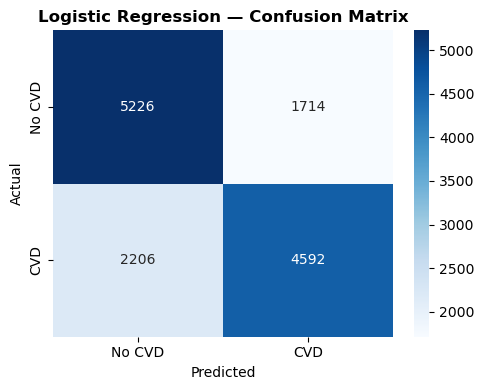

In [53]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No CVD","CVD"],yticklabels=["No CVD","CVD"])
plt.xlabel("Predicted");plt.ylabel("Actual");plt.title("Logistic Regression — Confusion Matrix",fontweight="bold")
plt.tight_layout();plt.show()

In [54]:
coef=pd.DataFrame({"Feature":X_train.columns,"Coefficient":lr.coef_[0]})
coef["Odds_Ratio"]=np.exp(coef["Coefficient"])
coef=coef.sort_values("Coefficient",ascending=False)
print(coef.to_string(index=False))

          Feature  Coefficient  Odds_Ratio
      systolic_bp     2.442093   11.497079
   pulse_pressure     2.419466   11.239858
     diastolic_bp     0.518360    1.679272
        age_years     0.369154    1.446511
      cholesterol     0.348463    1.416888
        weight_kg     0.164588    1.178908
              BMI     0.030054    1.030510
           gender     0.000021    1.000021
          smoking    -0.024696    0.975606
        height_cm    -0.032945    0.967591
      alcohol_use    -0.054329    0.947121
          glucose    -0.062261    0.939637
physically_active    -0.084263    0.919189


In [55]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
rf_prob=rf.predict_proba(X_test)[:,1]

In [56]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

print("Accuracy :",round(accuracy_score(y_test,rf_pred),4))
print("Precision:",round(precision_score(y_test,rf_pred),4))
print("Recall   :",round(recall_score(y_test,rf_pred),4))
print("F1-Score :",round(f1_score(y_test,rf_pred),4))
print("ROC-AUC  :",round(roc_auc_score(y_test,rf_prob),4))

Accuracy : 0.7069
Precision: 0.7075
Recall   : 0.6949
F1-Score : 0.7012
ROC-AUC  : 0.7672


In [57]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(rf,X_train,y_train,cv=cv,scoring="roc_auc",n_jobs=-1)

print("CV ROC-AUC:",np.round(cv_scores,4))
print("Mean CV ROC-AUC:",round(cv_scores.mean(),4))
print("Std:",round(cv_scores.std(),4))

CV ROC-AUC: [0.7807 0.7743 0.7763 0.7727 0.7706]
Mean CV ROC-AUC: 0.7749
Std: 0.0035


In [58]:
#Targeted Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid={
    "n_estimators":[200,300],
    "max_depth":[8,12,None],
    "min_samples_split":[2,5,10]}
grid=GridSearchCV(
    RandomForestClassifier(random_state=42,n_jobs=-1),
    param_grid,cv=cv,scoring="roc_auc",n_jobs=-1)
grid.fit(X_train,y_train)
print("Best parameters:",grid.best_params_)
print("Best CV ROC-AUC:",round(grid.best_score_,4))

Best parameters: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 300}
Best CV ROC-AUC: 0.8017


In [59]:
# Evaluate the Tuned Random Forest¶
best_rf=grid.best_estimator_
rf_pred=best_rf.predict(X_test)
rf_prob=best_rf.predict_proba(X_test)[:,1]

print("Accuracy :",round(accuracy_score(y_test,rf_pred),4))
print("Precision:",round(precision_score(y_test,rf_pred),4))
print("Recall   :",round(recall_score(y_test,rf_pred),4))
print("F1-Score :",round(f1_score(y_test,rf_pred),4))
print("ROC-AUC  :",round(roc_auc_score(y_test,rf_prob),4))

Accuracy : 0.7293
Precision: 0.7476
Recall   : 0.6837
F1-Score : 0.7143
ROC-AUC  : 0.7956


### Random Forest Confusion Matrix

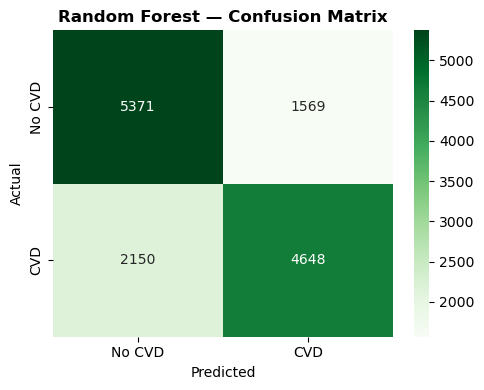

In [60]:
cm=confusion_matrix(y_test,rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["No CVD","CVD"],yticklabels=["No CVD","CVD"])
plt.xlabel("Predicted");plt.ylabel("Actual");plt.title("Random Forest — Confusion Matrix",fontweight="bold")
plt.tight_layout();plt.show()

In [61]:
# Final tuned Random Forest
best_rf=grid.best_estimator_
rf_pred=best_rf.predict(X_test)
rf_prob=best_rf.predict_proba(X_test)[:,1]

print("Accuracy :",round(accuracy_score(y_test,rf_pred),4))
print("Precision:",round(precision_score(y_test,rf_pred),4))
print("Recall   :",round(recall_score(y_test,rf_pred),4))
print("F1-Score :",round(f1_score(y_test,rf_pred),4))
print("ROC-AUC  :",round(roc_auc_score(y_test,rf_prob),4))

cm=confusion_matrix(y_test,rf_pred)
print("\nConfusion Matrix:\n",cm)

Accuracy : 0.7293
Precision: 0.7476
Recall   : 0.6837
F1-Score : 0.7143
ROC-AUC  : 0.7956

Confusion Matrix:
 [[5371 1569]
 [2150 4648]]


## Model Evaluation

In [62]:
# Predictions from both models
lr_pred=lr.predict(X_test_scaled)
lr_prob=lr.predict_proba(X_test_scaled)[:,1]

rf_pred=best_rf.predict(X_test)
rf_prob=best_rf.predict_proba(X_test)[:,1]

In [63]:
models=["Logistic Regression","Random Forest"]
results=pd.DataFrame({
    "Model":models,
    "Accuracy":[accuracy_score(y_test,lr_pred),accuracy_score(y_test,rf_pred)],
    "Precision":[precision_score(y_test,lr_pred),precision_score(y_test,rf_pred)],
    "Recall":[recall_score(y_test,lr_pred),recall_score(y_test,rf_pred)],
    "F1":[f1_score(y_test,lr_pred),f1_score(y_test,rf_pred)],
    "ROC-AUC":[roc_auc_score(y_test,lr_prob),roc_auc_score(y_test,rf_prob)]
}).round(4)

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.7147     0.7282  0.6755 0.7009   0.7790
      Random Forest    0.7293     0.7476  0.6837 0.7143   0.7956


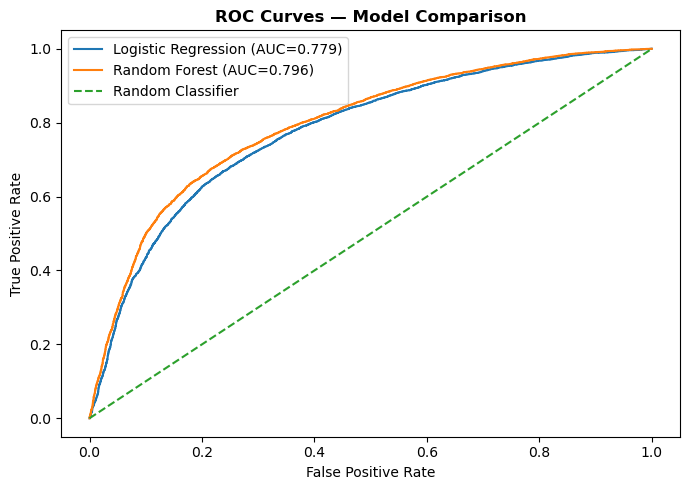

In [64]:
# ROC-AUC Curves
from sklearn.metrics import roc_curve,precision_recall_curve,average_precision_score

lr_fpr,lr_tpr,_=roc_curve(y_test,lr_prob)
rf_fpr,rf_tpr,_=roc_curve(y_test,rf_prob)

plt.figure(figsize=(7,5))
plt.plot(lr_fpr,lr_tpr,label=f"Logistic Regression (AUC={roc_auc_score(y_test,lr_prob):.3f})")
plt.plot(rf_fpr,rf_tpr,label=f"Random Forest (AUC={roc_auc_score(y_test,rf_prob):.3f})")
plt.plot([0,1],[0,1],"--",label="Random Classifier")
plt.xlabel("False Positive Rate");plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison",fontweight="bold")
plt.legend();plt.tight_layout();plt.show()

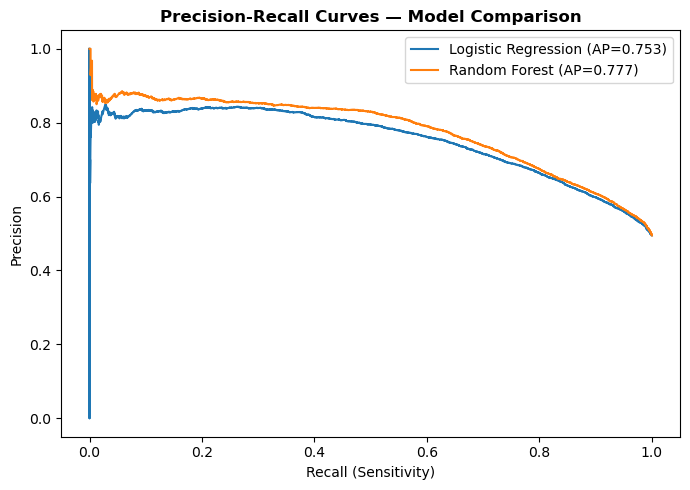

In [65]:
lr_p,lr_r,_=precision_recall_curve(y_test,lr_prob)
rf_p,rf_r,_=precision_recall_curve(y_test,rf_prob)

plt.figure(figsize=(7,5))
plt.plot(lr_r,lr_p,label=f"Logistic Regression (AP={average_precision_score(y_test,lr_prob):.3f})")
plt.plot(rf_r,rf_p,label=f"Random Forest (AP={average_precision_score(y_test,rf_prob):.3f})")
plt.xlabel("Recall (Sensitivity)");plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison",fontweight="bold")
plt.legend();plt.tight_layout();plt.show()

Random Forest performs better than Logistic Regression across all reported metrics.

- **ROC-AUC:** Random Forest (0.7956) > Logistic Regression (0.7790)
- **Recall:** Random Forest (0.6837) > Logistic Regression (0.6755)
- **Precision:** Random Forest (0.7476) > Logistic Regression (0.7282)
- **F1-Score:** Random Forest (0.7143) > Logistic Regression (0.7009)
- **Accuracy:** Random Forest (0.7293) > Logistic Regression (0.7147)

 **Among the two models evaluated, Random Forest currently provides stronger predictive performance than Logistic Regression and will be used as the provisional final model for further interpretation.**

In [66]:
from sklearn.metrics import confusion_matrix
thresholds=[0.30,0.40,0.50,0.60,0.70]
rows=[]
for t in thresholds:
    pred=(rf_prob>=t).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,pred).ravel()
    rows.append([t,accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred),fn,fp])

threshold_results=pd.DataFrame(rows,columns=["Threshold","Accuracy","Precision","Recall","F1","False_Negatives","False_Positives"]).round(4)
print(threshold_results.to_string(index=False))

 Threshold  Accuracy  Precision  Recall     F1  False_Negatives  False_Positives
       0.3    0.6818     0.6291  0.8697 0.7301              886             3485
       0.4    0.7177     0.6916  0.7752 0.7310             1528             2350
       0.5    0.7293     0.7476  0.6837 0.7143             2150             1569
       0.6    0.7211     0.7970  0.5855 0.6750             2818             1014
       0.7    0.7053     0.8232  0.5150 0.6336             3297              752


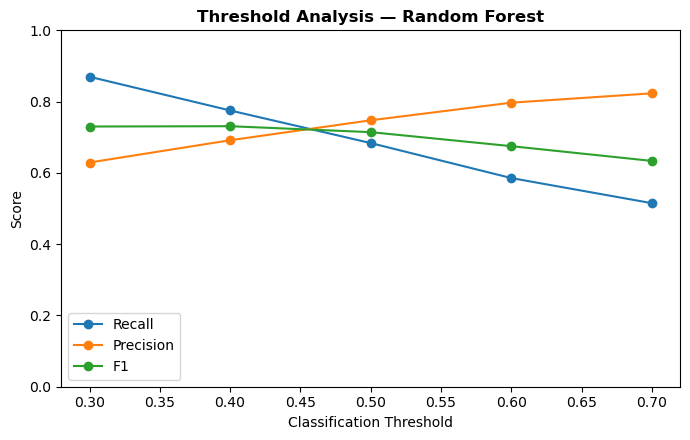

In [67]:
plt.figure(figsize=(7,4.5))
plt.plot(threshold_results["Threshold"],threshold_results["Recall"],marker="o",label="Recall")
plt.plot(threshold_results["Threshold"],threshold_results["Precision"],marker="o",label="Precision")
plt.plot(threshold_results["Threshold"],threshold_results["F1"],marker="o",label="F1")
plt.xlabel("Classification Threshold");plt.ylabel("Score")
plt.title("Threshold Analysis — Random Forest",fontweight="bold")
plt.ylim(0,1);plt.legend();plt.tight_layout();plt.show()

## Feature Importance

In [68]:
importance=pd.Series(best_rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)
print(importance)

systolic_bp          0.290862
diastolic_bp         0.155879
pulse_pressure       0.137463
age_years            0.132955
cholesterol          0.074820
BMI                  0.071052
weight_kg            0.054036
height_cm            0.040334
glucose              0.014613
physically_active    0.009957
gender               0.007002
smoking              0.005855
alcohol_use          0.005172
dtype: float64


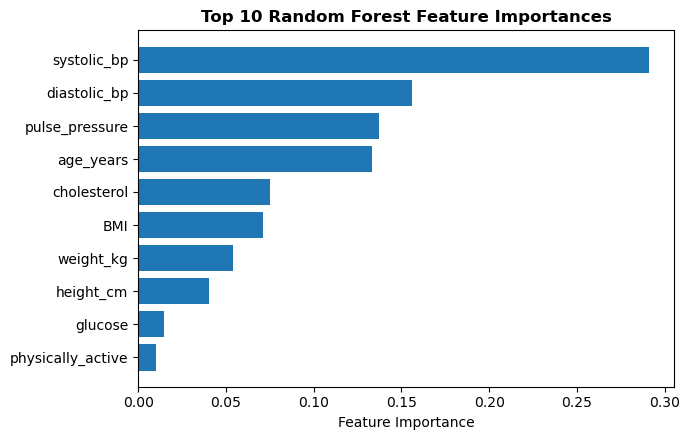

In [69]:
top=importance.head(10).sort_values()
plt.figure(figsize=(7,4.5))
plt.barh(top.index,top.values)
plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Feature Importances",fontweight="bold")
plt.tight_layout();plt.show()

In [70]:
from sklearn.inspection import permutation_importance

perm=permutation_importance(best_rf,X_test,y_test,n_repeats=10,scoring="roc_auc",random_state=42,n_jobs=-1)

perm_imp=pd.Series(perm.importances_mean,index=X_test.columns).sort_values(ascending=False)

print(perm_imp)

systolic_bp          0.109633
age_years            0.035223
cholesterol          0.026349
diastolic_bp         0.010333
pulse_pressure       0.006879
BMI                  0.002213
physically_active    0.002177
glucose              0.001879
weight_kg            0.001333
smoking              0.000796
gender               0.000521
height_cm            0.000380
alcohol_use          0.000219
dtype: float64


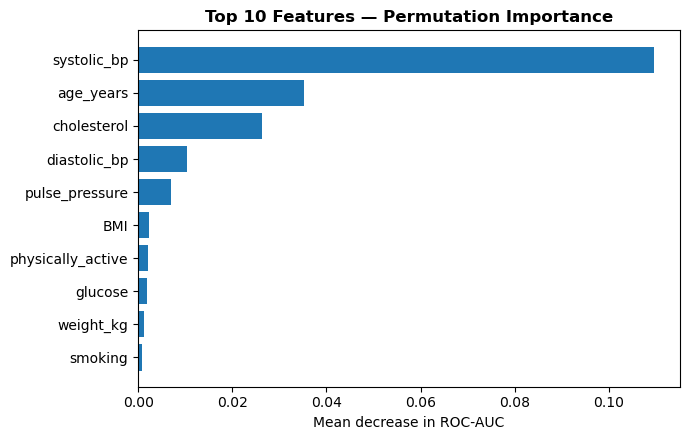

In [71]:
top=perm_imp.head(10).sort_values()
plt.figure(figsize=(7,4.5))
plt.barh(top.index,top.values)
plt.xlabel("Mean decrease in ROC-AUC")
plt.title("Top 10 Features — Permutation Importance",fontweight="bold")
plt.tight_layout();plt.show()

# Conclusion

This project analyzed cardiovascular disease data through a complete **EDA and machine-learning workflow**.

The analysis began with **70,000 records**, followed by data-quality cleaning and feature engineering. The final analytical dataset contained **68,688 records and 18 variables**.

EDA showed that **age, blood pressure, BMI, and cholesterol** had the clearest associations with CVD in the dataset. Multivariate analysis further showed that combinations of these factors provided meaningful differences in CVD prevalence.

Two classification models were developed:

- Logistic Regression
- Tuned Random Forest

The Random Forest achieved the stronger overall test performance, with:

> **72.93% Accuracy, 74.76% Precision, 68.37% Recall, 71.43% F1-Score, and 79.56% ROC-AUC.**

The model-interpretation results showed that **systolic blood pressure, age, cholesterol, diastolic blood pressure, and pulse pressure** were the most influential predictors.

Overall, the project demonstrates that cardiovascular disease presence can be studied using a combination of **data analysis, health-related feature engineering, and machine learning**, while also showing the importance of interpreting predictive results carefully rather than treating them as medical diagnosis.
